# **ANÁLISIS IMPAGO** #

# **Entendamos el negocio** #

- **OBJETIVO:**
Analizar y explicar el comportamiento del cambio climatico(CT) y una posible relación con el OHI(Ocean Health Index)

- **Entendamos los datos**

In [60]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
from io import StringIO
import re
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
#Carga de datos
OHI = pd.read_csv("ocean_health_index.csv", sep= ",")
CT = pd.read_csv(
    "Environment_Temperature_change_E_All_Data_NOFLAG.csv",
    encoding="latin1"
)

In [3]:
OHI.head(5)

,REF_AREA,REF_AREA_LABEL,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,Aruba,70.79,70.10,70.09,70.52,71.28,72.14,77.65,80.87,79.94,79.39,76.43,64.90,67.50
1,AGO,Angola,63.33,64.57,64.57,67.00,67.66,66.70,65.71,61.90,59.76,59.23,59.41,57.91,57.89
2,AIA,Anguilla,72.17,70.60,70.82,70.86,70.74,70.21,70.36,70.30,70.36,70.35,70.44,70.63,70.87
3,ALB,Albania,62.95,63.27,63.86,66.55,66.16,66.70,67.38,67.52,71.79,71.70,71.19,65.38,69.68
4,ANT,Netherlands Antilles,74.66,74.98,74.97,74.92,77.45,77.45,77.44,77.44,76.61,76.51,76.33,76.35,76.34


In [4]:
CT.head(10)

,Area Code,Area,Months Code,Months,Element Code,Element,Unit,Y1961,Y1962,Y1963,...,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019
0,2,Afghanistan,7001,January,7271,Temperature change,°C,0.777,0.062,2.744,...,3.601,1.179,-0.583,1.233,1.755,1.943,3.416,1.201,1.996,2.951
1,2,Afghanistan,7001,January,6078,Standard Deviation,°C,1.950,1.950,1.950,...,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950
2,2,Afghanistan,7002,February,7271,Temperature change,°C,-1.743,2.465,3.919,...,1.212,0.321,-3.201,1.494,-3.187,2.699,2.251,-0.323,2.705,0.086
3,2,Afghanistan,7002,February,6078,Standard Deviation,°C,2.597,2.597,2.597,...,2.597,2.597,2.597,2.597,2.597,2.597,2.597,2.597,2.597,2.597
4,2,Afghanistan,7003,March,7271,Temperature change,°C,0.516,1.336,0.403,...,3.390,0.748,-0.527,2.246,-0.076,-0.497,2.296,0.834,4.418,0.234
5,2,Afghanistan,7003,March,6078,Standard Deviation,°C,1.512,1.512,1.512,...,1.512,1.512,1.512,1.512,1.512,1.512,1.512,1.512,1.512,1.512
6,2,Afghanistan,7004,April,7271,Temperature change,°C,-1.709,0.117,0.919,...,2.591,1.712,1.417,-0.052,0.585,1.589,0.980,1.252,1.442,0.899
7,2,Afghanistan,7004,April,6078,Standard Deviation,°C,1.406,1.406,1.406,...,1.406,1.406,1.406,1.406,1.406,1.406,1.406,1.406,1.406,1.406
8,2,Afghanistan,7005,May,7271,Temperature change,°C,1.412,-0.092,-0.690,...,1.419,3.643,0.909,1.201,0.959,1.862,3.246,3.280,0.855,0.647
9,2,Afghanistan,7005,May,6078,Standard Deviation,°C,1.230,1.230,1.230,...,1.230,1.230,1.230,1.230,1.230,1.230,1.230,1.230,1.230,1.230


In [5]:
OHI.isnull().sum()

REF_AREA           0
REF_AREA_LABEL    13
2012              13
2013              13
2014              13
2015              13
2016              13
2017              13
2018              13
2019              13
2020              13
2021              13
2022              13
2023              13
2024              13
dtype: int64

In [6]:
OHI[OHI["2012"].isnull()].head(13)

,REF_AREA,REF_AREA_LABEL,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
17,"BHS,""Bahamas, The"",73.31,77.14,77.07,77.72,79....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,"COD,""Congo, Dem. Rep."",56.07,56.36,57.86,57.36...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,"COG,""Congo, Rep."",55.59,58.49,59.71,61.32,59.7...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,"EGY,""Egypt, Arab Rep."",73.0,72.58,69.84,69.61,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,"FSM,""Micronesia, Fed. Sts."",69.05,70.08,69.56,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,"GMB,""Gambia, The"",69.95,69.52,69.81,70.85,71.5...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,"IRN,""Iran, Islamic Rep."",68.81,71.42,71.93,71....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,"KOR,""Korea, Rep."",70.6,70.53,69.34,69.54,69.64...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,"PRK,""Korea, Dem. People's Rep."",60.77,59.52,60...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,"SHN,""Saint Helena, Ascension and Tristan da Cu...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Algunas filas se importaron como un solo string unido por comas en lugar de separar los valores en columnas, vamos a acomodarlas

In [7]:
with open('ocean_health_index.csv', 'r', encoding='utf-8') as f:
    raw_lines = f.readlines()

fixed_lines = []
for line in raw_lines:
    line = line.rstrip('\n')
    if line.startswith('"'):
        # Quitar comillas exteriores
        line = line[1:]
        if line.endswith('"'):
            line = line[:-1]
        # Reemplazar ""Nombre, Con Coma"" → "Nombre Con Coma"
        line = re.sub(r'""([^"]+)""', lambda m: '"' + m.group(1).replace(',', '') + '"', line)
    fixed_lines.append(line)

# Parsear el CSV corregido
from io import StringIO
csv_corregido = '\n'.join(fixed_lines)
OHI = pd.read_csv(StringIO(csv_corregido))

In [8]:
OHI.isnull().sum()

REF_AREA          0
REF_AREA_LABEL    0
2012              0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
2024              0
dtype: int64

In [9]:
OHI[OHI['REF_AREA'] == 'COD']

,REF_AREA,REF_AREA_LABEL,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
31,COD,Congo Dem. Rep.,56.07,56.36,57.86,57.36,56.84,59.01,59.16,60.97,61.79,59.31,57.43,52.83,54.8


In [10]:
CT.isnull().sum()


Area Code          0
Area               0
Months Code        0
Months             0
Element Code       0
                ... 
Y2015           1295
Y2016           1308
Y2017           1290
Y2018           1307
Y2019           1291
Length: 66, dtype: int64

In [11]:
CT[CT["Y2015"].isnull()].head(13)

,Area Code,Area,Months Code,Months,Element Code,Element,Unit,Y1961,Y1962,Y1963,...,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019
106,5,American Samoa,7003,March,7271,Temperature change,°C,-0.831,-0.108,0.039,...,1.171,0.620,0.320,1.020,NaN,NaN,NaN,NaN,NaN,NaN
107,5,American Samoa,7003,March,6078,Standard Deviation,°C,0.498,0.498,0.498,...,0.498,0.498,0.498,0.498,NaN,NaN,NaN,NaN,NaN,NaN
108,5,American Samoa,7004,April,7271,Temperature change,°C,0.068,0.145,-0.094,...,-0.930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109,5,American Samoa,7004,April,6078,Standard Deviation,°C,0.408,0.408,0.408,...,0.408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,5,American Samoa,7012,December,7271,Temperature change,°C,0.053,-0.395,0.015,...,-0.143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,5,American Samoa,7012,December,6078,Standard Deviation,°C,0.357,0.357,0.357,...,0.357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,5,American Samoa,7017,MarAprMay,7271,Temperature change,°C,-0.210,-0.091,0.039,...,0.382,0.760,0.463,1.345,NaN,NaN,NaN,NaN,NaN,NaN
129,5,American Samoa,7017,MarAprMay,6078,Standard Deviation,°C,0.332,0.332,0.332,...,0.332,0.332,0.332,0.332,NaN,NaN,NaN,NaN,NaN,NaN
341,1,Armenia,7001,January,6078,Standard Deviation,°C,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343,1,Armenia,7002,February,6078,Standard Deviation,°C,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Muchos años con datos nulos**

Anlicemos el comportamiento de los nulos

In [12]:
# Paso 1 — Filtrar solo temperatura anual (elimina meses, estaciones y SD)
CT = CT[
    (CT['Element'] == 'Temperature change') &
    (CT['Months'] == 'Meteorological year')
].copy()

In [13]:
# Paso 2 — Quedarse solo con columnas útiles
year_cols = [c for c in CT.columns if c.startswith('Y')]
CT = CT[['Area Code', 'Area'] + year_cols].reset_index(drop=True)

# Después de aplicar el filtro de Paso 1 y Paso 2
print("Shape:", CT.shape)
print(f"\nNaN por columna:")
print(CT[year_cols].isnull().sum())
print(f"\nTotal NaN: {CT[year_cols].isnull().sum().sum()}")


Shape: (284, 61)

NaN por columna:
Y1961    40
Y1962    39
Y1963    40
Y1964    42
Y1965    40
Y1966    37
Y1967    38
Y1968    38
Y1969    38
Y1970    39
Y1971    39
Y1972    38
Y1973    35
Y1974    36
Y1975    40
Y1976    42
Y1977    39
Y1978    36
Y1979    39
Y1980    39
Y1981    40
Y1982    39
Y1983    42
Y1984    39
Y1985    40
Y1986    39
Y1987    38
Y1988    39
Y1989    38
Y1990    39
Y1991    41
Y1992    23
Y1993    25
Y1994    25
Y1995    23
Y1996    21
Y1997    25
Y1998    22
Y1999    23
Y2000    22
Y2001    23
Y2002    21
Y2003    21
Y2004    19
Y2005    20
Y2006    17
Y2007    15
Y2008    17
Y2009    21
Y2010    19
Y2011    16
Y2012    21
Y2013    18
Y2014    19
Y2015    19
Y2016    20
Y2017    19
Y2018    19
Y2019    20
dtype: int64

Total NaN: 1781


In [14]:
# Ver qué países tienen NaN y en qué años
nan_paises = CT[CT[year_cols].isnull().any(axis=1)][['Area'] + year_cols]
print(f"\nPaíses con algún NaN: {len(nan_paises)}")
print(nan_paises)


Países con algún NaN: 83
                    Area  Y1961  Y1962  Y1963  Y1964  Y1965  Y1966  Y1967  \
3         American Samoa -0.014 -0.080  0.072 -0.226 -0.473  0.177 -0.402   
8    Antigua and Barbuda  0.057  0.070  0.308  0.214 -0.373  0.084 -0.259   
10               Armenia    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
11                 Aruba -0.232  0.072 -0.041  0.118 -0.237  0.050 -0.326   
14            Azerbaijan    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
..                   ...    ...    ...    ...    ...    ...    ...    ...   
236           Uzbekistan    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
240          Wake Island    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
243                Yemen  0.033 -0.006  0.168 -0.251 -0.624  0.087 -0.259   
244         Yugoslav SFR  0.922 -0.098 -0.272 -0.487 -0.532  0.686  0.273   
260         Central Asia    NaN    NaN    NaN    NaN    NaN    NaN    NaN   

     Y1968  Y1969  ...  Y2010  Y2011  Y2012  Y201

Se deja meteorological year, que es el promedio del cambio climatico calculado en el dataset, y se eliminan los meses anteriores y desviación estandar

In [15]:
CT.head(5)

,Area Code,Area,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,...,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019
0,2,Afghanistan,-0.080,-0.120,0.882,-0.727,-0.200,0.176,-0.361,-0.373,...,1.564,1.342,0.102,1.237,0.474,1.096,1.473,1.483,1.524,0.893
1,3,Albania,0.631,0.339,0.084,-0.171,-0.392,0.551,-0.084,0.071,...,1.294,1.123,1.603,1.495,1.399,1.725,1.697,1.337,2.232,1.911
2,4,Algeria,0.186,0.101,0.045,0.212,-0.135,0.404,-0.024,-0.079,...,2.359,1.492,1.238,1.267,1.774,1.224,1.866,1.630,1.326,1.224
3,5,American Samoa,-0.014,-0.080,0.072,-0.226,-0.473,0.177,-0.402,-0.181,...,1.271,0.790,0.901,1.159,1.086,0.885,1.648,1.268,1.101,1.502
4,6,Andorra,0.749,0.110,-0.755,0.305,-0.500,0.403,0.616,0.001,...,0.441,1.643,1.233,0.794,1.899,1.619,1.917,1.853,1.826,1.871


In [16]:
# Ver qué países tienen NaN y cuántos
nan_paises = CT[CT[year_cols].isnull().any(axis=1)][['Area'] + year_cols]
print(f"Países con algún NaN: {len(nan_paises)}")

# Ver cuántos NaN tiene cada país con NaN
ct_nan_count = CT[CT[year_cols].isnull().any(axis=1)].copy()
ct_nan_count['total_nan'] = ct_nan_count[year_cols].isnull().sum(axis=1)
print(ct_nan_count[['Area', 'total_nan']].sort_values('total_nan', ascending=False).to_string())

Países con algún NaN: 83
                                             Area  total_nan
205                                   South Sudan         50
208                                         Sudan         50
144                                    Montenegro         45
195                         Serbia and Montenegro         45
194                                        Serbia         45
141                                 Midway Island         43
150                                         Nauru         42
127                                    Luxembourg         39
20                                        Belgium         39
76                    Falkland Islands (Malvinas)         38
166                                         Palau         36
71                                        Eritrea         35
199                                      Slovakia         32
74                                       Ethiopia         32
59                                        Czechia         32

De esos paises nulos cuales estan en ambos dataset?

In [ ]:
# Países con algún NaN en CT
ct_con_nan = CT[CT[year_cols].isnull().any(axis=1)]['Area'].tolist()

# Países en OHI
ohi_paises = set(OHI['REF_AREA_LABEL'].str.strip())
ct_paises = set(CT['Area'].str.strip())

# De los 83 con NaN, ¿cuáles están en OHI?
nan_en_ohi = [p for p in ct_con_nan if p in ohi_paises]
nan_no_en_ohi = [p for p in ct_con_nan if p not in ohi_paises]

print(f"Con NaN que SÍ están en OHI: {len(nan_en_ohi)}")
print(nan_en_ohi)
print(f"\nCon NaN que NO están en OHI: {len(nan_no_en_ohi)}")
print(nan_no_en_ohi)

Con NaN que SÍ están en OHI: 43
['American Samoa', 'Antigua and Barbuda', 'Aruba', 'Barbados', 'Belgium', 'Bosnia and Herzegovina', 'Cabo Verde', 'Cayman Islands', 'Christmas Island', 'Comoros', 'Cook Islands', 'Costa Rica', 'Croatia', 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Georgia', 'Jamaica', 'Latvia', 'Lithuania', 'Maldives', 'Marshall Islands', 'Mayotte', 'Montenegro', 'Montserrat', 'Nauru', 'Niue', 'Palau', 'Panama', 'Russian Federation', 'Samoa', 'Sao Tome and Principe', 'Sierra Leone', 'Singapore', 'Slovenia', 'Solomon Islands', 'South Georgia and the South Sandwich Islands', 'Sudan', 'Timor-Leste', 'Trinidad and Tobago', 'Turks and Caicos Islands', 'Ukraine']

Con NaN que NO están en OHI: 40
['Armenia', 'Azerbaijan', 'Belarus', 'Belgium-Luxembourg', 'Burundi', 'Congo', 'Czechia', 'Czechoslovakia', 'Ethiopia', 'Ethiopia PDR', 'Falkland Islands (Malvinas)', 'French Southern and Antarctic Territories', 'Kazakhstan', 'Kiribati', 'Kyrgyzstan', 'Luxembourg', 'Microne

Nulos que no estan en OHI, pero si en CT

In [ ]:
# NaN por país de los que NO están en OHI
ct_nan_count = CT[year_cols].isnull().sum(axis=1)
CT['total_nan'] = ct_nan_count

resultado = CT[CT['Area'].isin(nan_no_en_ohi)][['Area', 'total_nan']].sort_values('total_nan', ascending=False)
print(resultado.to_string())

# Limpiar columna auxiliar
CT = CT.drop(columns=['total_nan'])



                                          Area  total_nan
205                                South Sudan         50
195                      Serbia and Montenegro         45
194                                     Serbia         45
141                              Midway Island         43
127                                 Luxembourg         39
76                 Falkland Islands (Malvinas)         38
59                                     Czechia         32
199                                   Slovakia         32
74                                    Ethiopia         32
224                               Turkmenistan         31
260                               Central Asia         31
236                                 Uzbekistan         31
14                                  Azerbaijan         31
19                                     Belarus         31
10                                     Armenia         31
215                                 Tajikistan         31
118           

Nulos que estan en OHI, y en CT

In [23]:
resultado = CT[CT['Area'].isin(nan_en_ohi)].copy()
resultado['total_nan'] = resultado[year_cols].isnull().sum(axis=1)
print(resultado[['Area', 'total_nan']].sort_values('total_nan', ascending=False).to_string())

                                             Area  total_nan
208                                         Sudan         50
144                                    Montenegro         45
150                                         Nauru         42
20                                        Belgium         39
166                                         Palau         36
71                                        Eritrea         35
120                                        Latvia         31
56                                        Croatia         31
126                                     Lithuania         31
26                         Bosnia and Herzegovina         31
182                            Russian Federation         31
72                                        Estonia         31
198                                     Singapore         31
228                                       Ukraine         31
200                                      Slovenia         31
86                      

Se interpolan los paises con <= 31 datos nulos, el resto se elimina

In [ ]:
# Calcular NaN por país
ct_nan_count = CT[year_cols].isnull().sum(axis=1)

UMBRAL = 31

# Eliminar países con más de 31 NaN
mask_eliminar = ct_nan_count > UMBRAL
print(f"Países eliminados (>{UMBRAL} NaN): {mask_eliminar.sum()}")
print(CT[mask_eliminar]['Area'].tolist())

CT = CT[~mask_eliminar].copy().reset_index(drop=True)

# Interpolar los restantes
CT[year_cols] = CT[year_cols].interpolate(method='linear', axis=1)
CT[year_cols] = CT[year_cols].fillna(method='bfill', axis=1)

print(f"\nShape final: {CT.shape}")

Países eliminados (>31 NaN): 15
['Belgium', 'Czechia', 'Eritrea', 'Ethiopia', 'Falkland Islands (Malvinas)', 'Luxembourg', 'Midway Island', 'Montenegro', 'Nauru', 'Palau', 'Serbia', 'Serbia and Montenegro', 'Slovakia', 'South Sudan', 'Sudan']

Shape final: (269, 61)
NaN restantes: 0


C:\Users\andre\AppData\Local\Temp\ipykernel_18200\3737858575.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  CT[year_cols] = CT[year_cols].fillna(method='bfill', axis=1)


**Se procede a hacer el modelo, pero que modelo funciona mejor?**

**Regresión Lineal**

In [57]:
year_nums = np.array([int(y[1:]) for y in year_cols])  # 1961–2019
predict_years = np.array([2020, 2021, 2022, 2023, 2024])

predictions = []

for _, row in CT.iterrows():
    vals = row[year_cols].values.astype(float)
    slope, intercept, r, p, se = stats.linregress(year_nums, vals)
    
    pred_vals = slope * predict_years + intercept
    
    entry = {'Area': row['Area'], 'Area Code': row['Area Code']}
    for y, v in zip(predict_years, pred_vals):
        entry[f'Y{y}'] = round(v, 3)
    predictions.append(entry)

CT_pred = pd.DataFrame(predictions)
print(CT_pred.head())
print(f"\nShape: {CT_pred.shape}")


             Area  Area Code  Y2020  Y2021  Y2022  Y2023  Y2024
0     Afghanistan          2  1.213  1.239  1.265  1.291  1.317
1         Albania          3  1.451  1.483  1.515  1.547  1.579
2         Algeria          4  1.741  1.775  1.810  1.844  1.878
3  American Samoa          5  1.276  1.303  1.329  1.355  1.381
4         Andorra          6  1.709  1.743  1.777  1.811  1.845

Shape: (269, 7)


In [61]:
# Estrategia: entrenar con 1961–2009, predecir 2010–2019 (10 años conocidos)
train_years = np.array([int(y[1:]) for y in year_cols if int(y[1:]) <= 2009])
test_years  = np.array([int(y[1:]) for y in year_cols if int(y[1:]) >= 2010])

resultados = []

for _, row in CT.iterrows():
    vals = row[year_cols].values.astype(float)
    
    y_train = vals[:len(train_years)]
    y_test  = vals[len(train_years):]
    
    slope, intercept, r, p, se = stats.linregress(train_years, y_train)
    y_pred = slope * test_years + intercept
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    resultados.append({
        'Area': row['Area'],
        'MAE':  round(mae, 3),
        'RMSE': round(rmse, 3),
        'R²':   round(r2, 3)
    })

results_df = pd.DataFrame(resultados).sort_values('MAE')

print("=== MÉTRICAS GLOBALES REGRESIÓN LINEAL ===")
print(f"MAE  promedio: {results_df['MAE'].mean():.3f}°C")
print(f"RMSE promedio: {results_df['RMSE'].mean():.3f}°C")
print(f"R²   promedio: {results_df['R²'].mean():.3f}")

print("\n=== MEJORES 5 países (menor error) ===")
print(results_df.head(5).to_string())

=== MÉTRICAS GLOBALES REGRESIÓN LINEAL ===
MAE  promedio: 0.344°C
RMSE promedio: 0.416°C
R²   promedio: -531034928810569010894224752640.000

=== MEJORES 5 países (menor error) ===
             Area    MAE   RMSE            R²
229  Yugoslav SFR  0.021  0.023 -2.652422e+30
125      Maldives  0.083  0.093  3.140000e-01
204       Tokelau  0.088  0.107  0.000000e+00
186     Singapore  0.090  0.090 -4.230898e+31
32        Burundi  0.092  0.097 -8.032000e+00


- **MAE promedio: 0.344°C** El modelo se equivoca en promedio ±0.344°C por año por país. Para anomalías de temperatura que oscilan entre -1°C y +3°C, ese error es considerable.
- **RMSE promedio: 0.416°C** Mayor que el MAE, lo que confirma que hay países con errores muy grandes que están jalando el promedio hacia arriba.
- **R² promedio: -531034928810569010...** Este número es un error de cómputo, no un resultado real. Un R² nunca puede ser menor que -1 en términos prácticos — ese valor absurdo indica que algún país tiene una serie con valores extremos o constantes que hace explotar el cálculo.

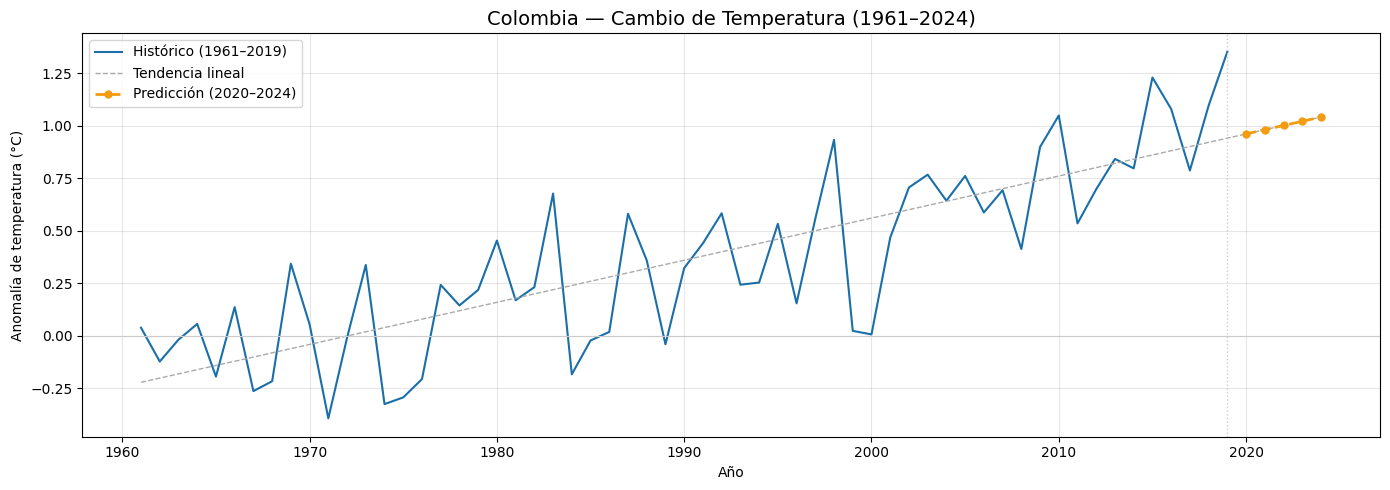


R²: 0.658 | Pendiente: 0.0201°C/año

Predicciones Colombia:
  2020: 0.961°C
  2021: 0.981°C
  2022: 1.001°C
  2023: 1.021°C
  2024: 1.041°C


In [59]:
# Datos históricos de Colombia
col_hist = CT[CT['Area'] == 'Colombia'][year_cols].values.flatten()

# Modelo lineal
slope, intercept, r, p, se = stats.linregress(year_nums, col_hist)

# Predicciones 2020-2024
pred_vals = slope * predict_years + intercept

# Graficar
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(year_nums, col_hist, color='#1a6fa8', linewidth=1.5, label='Histórico (1961–2019)')

trend_full = slope * np.append(year_nums, predict_years) + intercept
ax.plot(np.append(year_nums, predict_years), trend_full,
        color='#aaaaaa', linewidth=1, linestyle='--', label='Tendencia lineal')

ax.plot(predict_years, pred_vals, color='#f39c12', linewidth=2,
        linestyle='--', marker='o', markersize=5, label='Predicción (2020–2024)')

ax.axvline(x=2019, color='#cccccc', linestyle=':', linewidth=1)
ax.axhline(y=0, color='#cccccc', linestyle='-', linewidth=0.8)

ax.set_title('Colombia — Cambio de Temperatura (1961–2024)', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía de temperatura (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nR²: {r**2:.3f} | Pendiente: {slope:.4f}°C/año")
print("\nPredicciones Colombia:")
for y, v in zip(predict_years, pred_vals):
    print(f"  {y}: {v:.3f}°C")

**ARIMA**

In [62]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

predict_years = [2020, 2021, 2022, 2023, 2024]
predicciones_arima = []

for _, row in CT.iterrows():
    vals = row[year_cols].values.astype(float)
    
    try:
        # Ajustar ARIMA(1,1,1) sobre la serie histórica 1961–2019
        modelo = ARIMA(vals, order=(1, 1, 1))
        resultado = modelo.fit()
        
        # Predecir los 5 años siguientes
        pred = resultado.forecast(steps=5)
        
        entry = {'Area': row['Area'], 'Area Code': row['Area Code']}
        for y, v in zip(predict_years, pred):
            entry[f'Y{y}'] = round(v, 3)
        predicciones_arima.append(entry)
        
    except Exception as e:
        print(f"Error en {row['Area']}: {e}")

CT_pred_arima = pd.DataFrame(predicciones_arima)
CT_pred_arima = pd.DataFrame(predictions)
print(CT_pred_arima.head())
print(f"\nShape: {CT_pred_arima.shape}")


             Area  Area Code  Y2020  Y2021  Y2022  Y2023  Y2024
0     Afghanistan          2  1.213  1.239  1.265  1.291  1.317
1         Albania          3  1.451  1.483  1.515  1.547  1.579
2         Algeria          4  1.741  1.775  1.810  1.844  1.878
3  American Samoa          5  1.276  1.303  1.329  1.355  1.381
4         Andorra          6  1.709  1.743  1.777  1.811  1.845

Shape: (269, 7)


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

train_years_idx = [i for i, y in enumerate(year_cols) if int(y[1:]) <= 2009]
test_years_idx  = [i for i, y in enumerate(year_cols) if int(y[1:]) >= 2010]

resultados_arima = []

for _, row in CT.iterrows():
    vals = row[year_cols].values.astype(float)
    
    y_train = vals[train_years_idx]
    y_test  = vals[test_years_idx]
    
    try:
        modelo = ARIMA(y_train, order=(1, 1, 1))
        resultado = modelo.fit()
        y_pred = resultado.forecast(steps=len(test_years_idx))
        
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)
        
        resultados_arima.append({
            'Area': row['Area'],
            'MAE':  round(mae, 3),
            'RMSE': round(rmse, 3),
            'R²':   round(r2, 3)
        })
    except Exception as e:
        print(f"Error en {row['Area']}: {e}")

arima_df = pd.DataFrame(resultados_arima)
arima_clean = arima_df[arima_df['R²'].between(-10, 1)]

print("=== MÉTRICAS GLOBALES ARIMA ===")
print(f"MAE  promedio: {arima_clean['MAE'].mean():.3f}°C")
print(f"RMSE promedio: {arima_clean['RMSE'].mean():.3f}°C")
print(f"R²   promedio: {arima_clean['R²'].mean():.3f}")

=== MÉTRICAS GLOBALES ARIMA ===
MAE  promedio: 0.422°C
RMSE promedio: 0.502°C
R²   promedio: -1.271


- **MAE promedio: 0.422°C**
El modelo se equivoca en promedio ±0.422°C por año por país. Lo que indica que ARIMA sigue el ruido reciente de la serie en lugar de la tendencia de largo plazo.

- **RMSE promedio: 0.502°C**
Mayor que el MAE, confirmando que hay países donde el error es especialmente grande. ARIMA penaliza más en series con alta variabilidad inter-anual como las de temperatura.

- **R² promedio: -1.271**
Un R² negativo significa que el modelo es peor que predecir simplemente la media histórica. En ARIMA esto ocurre porque con solo 10 años de predicción y series muy ruidosas, el modelo sobreajusta al comportamiento reciente y pierde la tendencia global de calentamiento.

**Media Movil**

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

VENTANA = 5
train_years_idx = [i for i, y in enumerate(year_cols) if int(y[1:]) <= 2009]
test_years_idx  = [i for i, y in enumerate(year_cols) if int(y[1:]) >= 2010]

resultados_mm = []

for _, row in CT.iterrows():
    vals = row[year_cols].values.astype(float)
    
    y_train = list(vals[train_years_idx])
    y_test  = vals[test_years_idx]
    
    # Predecir año a año con ventana móvil
    serie = y_train.copy()
    y_pred = []
    for _ in range(len(test_years_idx)):
        next_val = np.mean(serie[-VENTANA:])
        y_pred.append(next_val)
        serie.append(next_val)
    
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    resultados_mm.append({
        'Area': row['Area'],
        'MAE':  round(mae, 3),
        'RMSE': round(rmse, 3),
        'R²':   round(r2, 3)
    })

mm_df = pd.DataFrame(resultados_mm)
mm_clean = mm_df[mm_df['R²'].between(-10, 1)]

print("=== MÉTRICAS GLOBALES MEDIA MÓVIL ===")
print(f"MAE  promedio: {mm_clean['MAE'].mean():.3f}°C")
print(f"RMSE promedio: {mm_clean['RMSE'].mean():.3f}°C")
print(f"R²   promedio: {mm_clean['R²'].mean():.3f}")

=== MÉTRICAS GLOBALES MEDIA MÓVIL ===
MAE  promedio: 0.388°C
RMSE promedio: 0.465°C
R²   promedio: -1.003


- **MAE promedio: 0.388°C**
El modelo se equivoca en promedio ±0.388°C por año por país. Mejor que ARIMA pero peor que la regresión lineal. La media móvil sigue el nivel reciente de la serie sin asumir tendencia, lo que la hace más conservadora pero menos precisa para series con calentamiento sostenido.

- **RMSE promedio: 0.465°C**
Mayor que el MAE, indicando que hay países con errores puntuales grandes. Ocurre porque cuando la temperatura sube consistentemente, la media móvil siempre va "atrasada" respecto al valor real.

- **R² promedio: -1.003**
Negativo, lo que significa que predecir la media histórica sería igual de efectivo. La media móvil con ventana de 5 años suaviza demasiado la tendencia de calentamiento, perdiendo capacidad predictiva en el mediano plazo.

- **Conclusión:** Se usa Regresión lineal ya que presenta mejores métricas de MAE y RMSE.
- **El R² negativo en ambos modelos no significa que sean inútiles** significa que la variabilidad inter-anual de temperatura es inherentemente impredecible con cualquier modelo. 

In [66]:
predict_years = [2020, 2021, 2022, 2023, 2024]
year_nums = np.array([int(y[1:]) for y in year_cols])  # 1961–2019

predicciones_rl = []

for _, row in CT.iterrows():
    vals = row[year_cols].values.astype(float)
    slope, intercept, r, p, se = stats.linregress(year_nums, vals)
    
    entry = {'Area': row['Area'], 'Area Code': row['Area Code']}
    for y in predict_years:
        entry[f'Y{y}'] = round(slope * y + intercept, 3)
    predicciones_rl.append(entry)

pred_df = pd.DataFrame(predicciones_rl)

# Añadir las predicciones al dataset original
CT_predicciones = CT.merge(pred_df, on=['Area', 'Area Code'])
CT_predicciones.head(5)



,Area Code,Area,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,...,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023,Y2024
0,2,Afghanistan,-0.080,-0.120,0.882,-0.727,-0.200,0.176,-0.361,-0.373,...,1.096,1.473,1.483,1.524,0.893,1.213,1.239,1.265,1.291,1.317
1,3,Albania,0.631,0.339,0.084,-0.171,-0.392,0.551,-0.084,0.071,...,1.725,1.697,1.337,2.232,1.911,1.451,1.483,1.515,1.547,1.579
2,4,Algeria,0.186,0.101,0.045,0.212,-0.135,0.404,-0.024,-0.079,...,1.224,1.866,1.630,1.326,1.224,1.741,1.775,1.810,1.844,1.878
3,5,American Samoa,-0.014,-0.080,0.072,-0.226,-0.473,0.177,-0.402,-0.181,...,0.885,1.648,1.268,1.101,1.502,1.276,1.303,1.329,1.355,1.381
4,6,Andorra,0.749,0.110,-0.755,0.305,-0.500,0.403,0.616,0.001,...,1.619,1.917,1.853,1.826,1.871,1.709,1.743,1.777,1.811,1.845


Se hace nuevo dataset OHI_CT que incluye los datos del dataset CT a OHI para hacer modelado de 2025-2030

In [75]:
# Inner join por nombre exacto primero
CT_rename = CT_full[['Area'] + [c for c in CT_full.columns if c.startswith('Y')]].copy()
CT_rename = CT_rename.rename(columns={'Area': 'REF_AREA_LABEL'})

OHI_CT = pd.merge(
    OHI,
    CT_rename,
    on='REF_AREA_LABEL',
    how='inner'
)

print(f"Shape: {OHI_CT.shape}")

Shape: (146, 79)


In [76]:
OHI_CT.head(5)

,REF_AREA,REF_AREA_LABEL,2012,2013,2014,2015,2016,2017,2018,2019,...,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023,Y2024
0,ABW,Aruba,70.79,70.10,70.09,70.52,71.28,72.14,77.65,80.87,...,1.601,1.000,1.143,0.895,1.216,1.058,1.079,1.100,1.121,1.142
1,AGO,Angola,63.33,64.57,64.57,67.00,67.66,66.70,65.71,61.90,...,1.260,1.534,0.808,1.264,1.694,1.036,1.056,1.077,1.098,1.119
2,AIA,Anguilla,72.17,70.60,70.82,70.86,70.74,70.21,70.36,70.30,...,0.916,0.954,0.788,0.607,0.843,0.750,0.767,0.783,0.800,0.816
3,ALB,Albania,62.95,63.27,63.86,66.55,66.16,66.70,67.38,67.52,...,1.725,1.697,1.337,2.232,1.911,1.451,1.483,1.515,1.547,1.579
4,ARE,United Arab Emirates,82.74,82.13,82.86,83.49,83.44,84.35,85.03,85.07,...,1.498,0.975,1.613,1.489,1.151,1.070,1.095,1.120,1.144,1.169


Primero veamos si hay relación

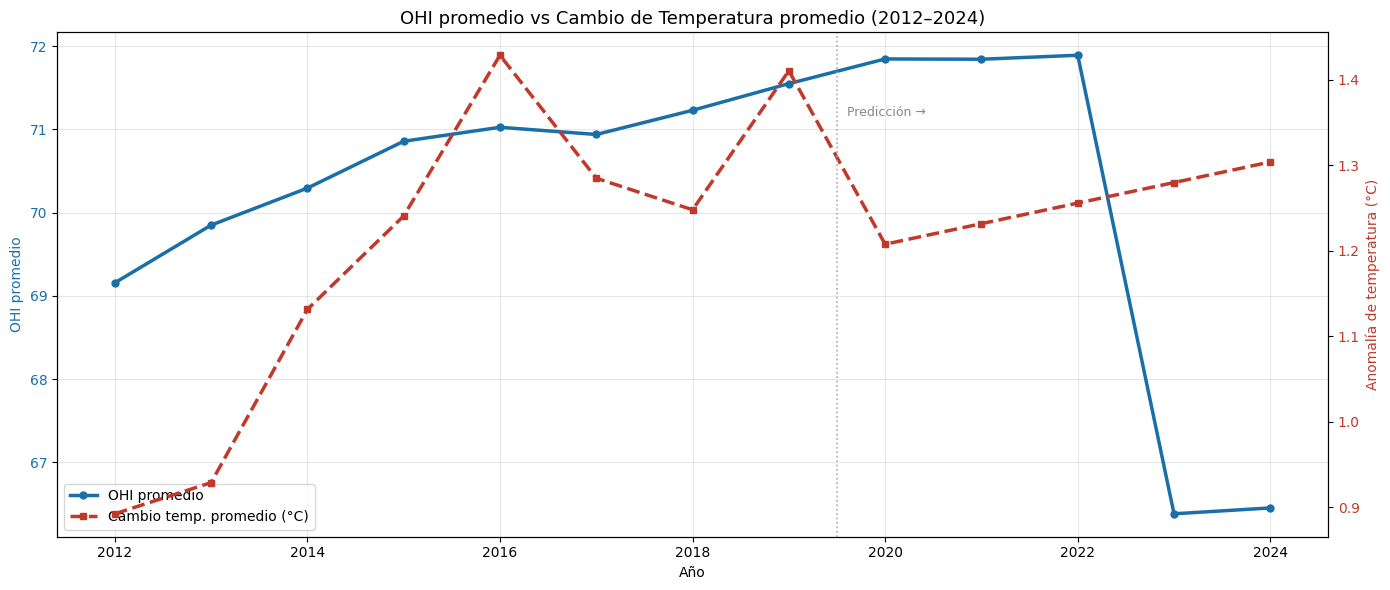

In [77]:
# Años en común entre CT y OHI
ohi_years = [str(y) for y in range(2012, 2025)]
ct_years  = [f'Y{y}' for y in range(2012, 2025)]

# Promedios globales por año
ohi_means = [OHI_CT[y].mean() for y in ohi_years]
ct_means  = [OHI_CT[y].mean() for y in ct_years]

years = list(range(2012, 2025))

# Graficar
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo — OHI
color_ohi = '#1a6fa8'
ax1.plot(years, ohi_means, color=color_ohi, linewidth=2.5,
         marker='o', markersize=5, label='OHI promedio')
ax1.set_xlabel('Año')
ax1.set_ylabel('OHI promedio', color=color_ohi)
ax1.tick_params(axis='y', labelcolor=color_ohi)

# Eje derecho — Temperatura
ax2 = ax1.twinx()
color_ct = '#c0392b'
ax2.plot(years, ct_means, color=color_ct, linewidth=2.5,
         marker='s', markersize=5, linestyle='--', label='Cambio temp. promedio (°C)')
ax2.set_ylabel('Anomalía de temperatura (°C)', color=color_ct)
ax2.tick_params(axis='y', labelcolor=color_ct)

# Separar histórico de predicción en CT
ax2.axvline(x=2019.5, color='#aaaaaa', linestyle=':', linewidth=1.2)
ax2.text(2019.6, max(ct_means)*0.95, 'Predicción →', fontsize=9, color='#888888')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

ax1.set_title('OHI promedio vs Cambio de Temperatura promedio (2012–2024)', fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**No se encuentra tendencia clara**, depronto incluyendo todos los paises de CT?

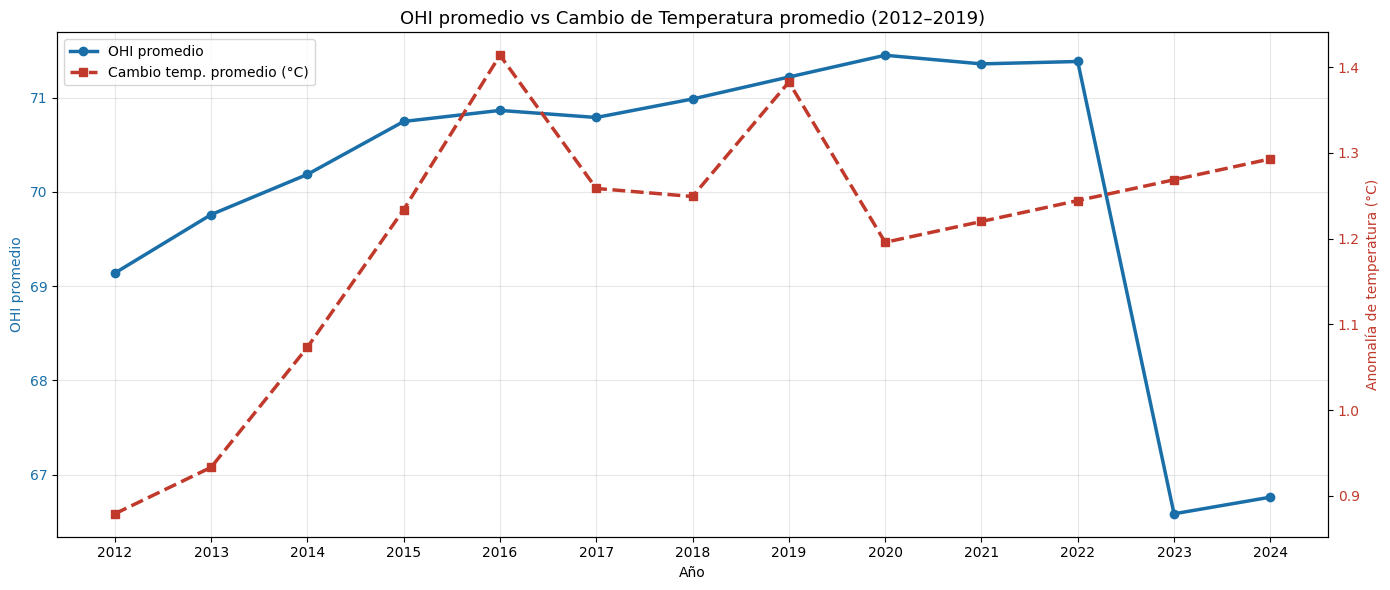

In [92]:
import matplotlib.pyplot as plt

ohi_years = [str(y) for y in range(2012, 2025)]
ct_years  = [f'Y{y}' for y in range(2012, 2025)]
years     = list(range(2012, 2025))

ohi_means = [
    OHI[y].mean() for y in ohi_years]
ct_means  = [CT_full[y].mean() for y in ct_years]

fig, ax1 = plt.subplots(figsize=(14, 6))

color_ohi = '#1a6fa8'
ax1.plot(years, ohi_means, color=color_ohi, linewidth=2.5,
         marker='o', markersize=6, label='OHI promedio')
ax1.set_xlabel('Año')
ax1.set_ylabel('OHI promedio', color=color_ohi)
ax1.tick_params(axis='y', labelcolor=color_ohi)

ax2 = ax1.twinx()
color_ct = '#c0392b'
ax2.plot(years, ct_means, color=color_ct, linewidth=2.5,
         marker='s', markersize=6, linestyle='--', label='Cambio temp. promedio (°C)')
ax2.set_ylabel('Anomalía de temperatura (°C)', color=color_ct)
ax2.tick_params(axis='y', labelcolor=color_ct)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('OHI promedio vs Cambio de Temperatura promedio (2012–2019)', fontsize=13)
ax1.set_xticks(years)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Tendencia visible** con matices importantes:
- Entre 2012 y 2016 hay una correlación positiva clara — ambas variables suben juntas. A medida que la temperatura aumenta, el OHI también sube. Esto es contraintuitivo — esperaríamos que más calor = peor salud oceánica.
- Entre 2016 y 2018 se rompe esa relación — la temperatura baja ligeramente y el OHI también baja un poco, pero luego en 2019 ambas vuelven a subir juntas.
- Sin embargo el drop metodológico de 2023 distorsiona todo.

Se entrena con regresión lineal

In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

predicciones_ohi = []

for pais in train_df['Country'].unique():
    df_pais = train_df[train_df['Country'] == pais].copy()
    
    if len(df_pais) < 5:
        continue
    
    X = df_pais[['Year', 'CT']].values
    y = df_pais['OHI'].values
    
    modelo_pais = LinearRegression()
    modelo_pais.fit(X, y)
    
    # Métricas
    y_pred = modelo_pais.predict(X)
    mae = mean_absolute_error(y, y_pred)
    r2  = r2_score(y, y_pred)
    
    # CT promedio de los últimos 5 años conocidos (2018–2022) para proyectar
    ct_row = CT_full[CT_full['Area'] == pais].iloc[0]
    ct_reciente = np.mean([ct_row[f'Y{y}'] for y in range(2018, 2023)])
    
    entry = {'Country': pais, 'MAE': round(mae, 3), 'R²': round(r2, 3)}
    for yr in predict_years:
        pred = modelo_pais.predict([[yr, ct_reciente]])[0]
        entry[f'OHI_{yr}'] = round(pred, 2)
    predicciones_ohi.append(entry)

pred_ohi_df = pd.DataFrame(predicciones_ohi)

print(f"\n=== MÉTRICAS GLOBALES ===")
print(f"MAE  promedio: {pred_ohi_df['MAE'].mean():.3f}")
print(f"R²   promedio: {pred_ohi_df['R²'].mean():.3f}")


=== MÉTRICAS GLOBALES ===
MAE  promedio: 0.802
R²   promedio: 0.617


In [97]:
from sklearn.metrics import mean_absolute_error, r2_score

VENTANA = 5
predict_years = list(range(2025, 2031))

predicciones_ohi = []

for pais in train_df['Country'].unique():
    df_pais = train_df[train_df['Country'] == pais].sort_values('Year').copy()
    
    if len(df_pais) < 5:
        continue
    
    ohi_vals = list(df_pais['OHI'].values)
    
    # Backtesting — últimos 5 años como test
    y_train = ohi_vals[:-5]
    y_test  = ohi_vals[-5:]
    
    serie = y_train.copy()
    y_pred_test = []
    for _ in range(5):
        next_val = np.mean(serie[-VENTANA:])
        y_pred_test.append(next_val)
        serie.append(next_val)
    
    mae = mean_absolute_error(y_test, y_pred_test)
    r2  = r2_score(y_test, y_pred_test)
    
    # Predecir 2025–2030 partiendo de la serie completa
    serie_full = ohi_vals.copy()
    preds = []
    for _ in predict_years:
        next_val = np.mean(serie_full[-VENTANA:])
        preds.append(round(next_val, 2))
        serie_full.append(next_val)
    
    entry = {'Country': pais, 'MAE': round(mae, 3), 'R²': round(r2, 3)}
    for yr, v in zip(predict_years, preds):
        entry[f'OHI_{yr}'] = v
    predicciones_ohi.append(entry)

pred_ohi_df = pd.DataFrame(predicciones_ohi)

print(f"\n=== MÉTRICAS GLOBALES ===")
print(f"MAE  promedio: {pred_ohi_df['MAE'].mean():.3f}")
print(f"R²   promedio: {pred_ohi_df['R²'].mean():.3f}")


=== MÉTRICAS GLOBALES ===
MAE  promedio: 2.172
R²   promedio: -14.711


**Usamos regresión lineal**

In [98]:
from sklearn.linear_model import LinearRegression

predict_years = list(range(2025, 2031))
predicciones_ohi = []

for pais in train_df['Country'].unique():
    df_pais = train_df[train_df['Country'] == pais].sort_values('Year').copy()
    
    if len(df_pais) < 5:
        continue
    
    X = df_pais[['Year', 'CT']].values
    y = df_pais['OHI'].values
    
    modelo_pais = LinearRegression()
    modelo_pais.fit(X, y)
    
    # Métricas
    y_pred = modelo_pais.predict(X)
    mae = mean_absolute_error(y, y_pred)
    r2  = r2_score(y, y_pred)
    
    # CT promedio 2018–2022 para proyectar
    ct_row = CT_full[CT_full['Area'] == pais].iloc[0]
    ct_reciente = np.mean([ct_row[f'Y{y}'] for y in range(2018, 2023)])
    
    entry = {'Country': pais, 'MAE': round(mae, 3), 'R²': round(r2, 3)}
    for yr in predict_years:
        pred = modelo_pais.predict([[yr, ct_reciente]])[0]
        entry[f'OHI_{yr}'] = round(pred, 2)
    predicciones_ohi.append(entry)

pred_ohi_df = pd.DataFrame(predicciones_ohi)

# Añadir predicciones al dataset OHI
pred_merge = pred_ohi_df[['Country'] + [f'OHI_{y}' for y in predict_years]].rename(columns={'Country': 'REF_AREA_LABEL'})
pred_merge = pred_merge.rename(columns={f'OHI_{y}': str(y) for y in predict_years})

OHI_full = pd.merge(OHI, pred_merge, on='REF_AREA_LABEL', how='left')

print(f"Shape OHI_full: {OHI_full.shape}")
print(f"Columnas: {OHI_full.columns.tolist()}")
print(f"NaN en años predichos: {OHI_full[['2025','2026','2027','2028','2029','2030']].isnull().sum().sum()}")


Shape OHI_full: (194, 21)
Columnas: ['REF_AREA', 'REF_AREA_LABEL', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030']
NaN en años predichos: 288


In [100]:
# Mapeo de nombres OHI → CT
nombre_map = {
    'Turkiye':                                    'Turkey',
    'United States':                              'United States of America',
    'Egypt Arab Rep.':                            'Egypt',
    'Iran Islamic Rep.':                          'Iran (Islamic Republic of)',
    'Congo Dem. Rep.':                            'Democratic Republic of the Congo',
    'Congo Rep.':                                 'Congo',
    "Cote d'Ivoire":                              "Côte d'Ivoire",
    'Korea Rep.':                                 'Republic of Korea',
    "Korea Dem. People's Rep.":                   "Democratic People's Republic of Korea",
    'Venezuela':                                  'Venezuela (Bolivarian Republic of)',
    'Tanzania':                                   'United Republic of Tanzania',
    'Yemen Rep.':                                 'Yemen',
    'Sudan':                                      'Sudan',
    'Montenegro':                                 'Montenegro',
    'Bahamas The':                                'Bahamas',
    'Gambia The':                                 'Gambia',
    'Reunion':                                    'Réunion',
    'Taiwan China':                               'Taiwan',
    'Micronesia Fed. Sts.':                       'Micronesia (Federated States of)',
    'St. Kitts and Nevis':                        'Saint Kitts and Nevis',
    'St. Lucia':                                  'Saint Lucia',
    'St. Vincent and the Grenadines':             'Saint Vincent and the Grenadines',
}

# Aplicar mapeo y reentrenar solo para estos países
rows_extra = []

for ohi_name, ct_name in nombre_map.items():
    ohi_match = OHI[OHI['REF_AREA_LABEL'] == ohi_name]
    ct_match  = CT_full[CT_full['Area'] == ct_name]
    
    if ohi_match.empty or ct_match.empty:
        continue
    
    ohi_row = ohi_match.iloc[0]
    ct_row  = ct_match.iloc[0]
    
    for y in train_years:
        ohi_val = pd.to_numeric(ohi_row[str(y)], errors='coerce')
        ct_val  = pd.to_numeric(ct_row[f'Y{y}'], errors='coerce')
        if pd.isna(ohi_val) or pd.isna(ct_val):
            continue
        rows_extra.append({
            'Country': ohi_name,
            'Year':    y,
            'CT':      ct_val,
            'OHI':     ohi_val
        })

train_extra = pd.DataFrame(rows_extra)
print(f"Países extra recuperados: {train_extra['Country'].nunique()}")
print(train_extra['Country'].unique())

Países extra recuperados: 19
['Turkiye' 'United States' 'Egypt Arab Rep.' 'Iran Islamic Rep.'
 'Congo Dem. Rep.' 'Congo Rep.' "Cote d'Ivoire" 'Korea Rep.'
 "Korea Dem. People's Rep." 'Venezuela' 'Tanzania' 'Yemen Rep.'
 'Bahamas The' 'Gambia The' 'Reunion' 'Micronesia Fed. Sts.'
 'St. Kitts and Nevis' 'St. Lucia' 'St. Vincent and the Grenadines']


In [101]:
pred_extra = []

for pais in train_extra['Country'].unique():
    df_pais = train_extra[train_extra['Country'] == pais].sort_values('Year').copy()
    
    if len(df_pais) < 5:
        continue
    
    X = df_pais[['Year', 'CT']].values
    y = df_pais['OHI'].values
    
    modelo_pais = LinearRegression()
    modelo_pais.fit(X, y)
    
    # CT reciente del país mapeado
    ct_name = nombre_map[pais]
    ct_row = CT_full[CT_full['Area'] == ct_name].iloc[0]
    ct_reciente = np.mean([ct_row[f'Y{y}'] for y in range(2018, 2023)])
    
    entry = {'REF_AREA_LABEL': pais}
    for yr in predict_years:
        pred = modelo_pais.predict([[yr, ct_reciente]])[0]
        entry[str(yr)] = round(pred, 2)
    pred_extra.append(entry)

pred_extra_df = pd.DataFrame(pred_extra)
print(f"Países extra con predicción: {len(pred_extra_df)}")

# Actualizar OHI_full con las predicciones extra
for _, row in pred_extra_df.iterrows():
    pais = row['REF_AREA_LABEL']
    for yr in predict_years:
        OHI_full.loc[OHI_full['REF_AREA_LABEL'] == pais, str(yr)] = row[str(yr)]

print(f"\nNaN restantes en años predichos: {OHI_full[['2025','2026','2027','2028','2029','2030']].isnull().sum().sum()}")
print(f"\nPaíses sin predicción restantes: {OHI_full['2025'].isnull().sum()}")
print(OHI_full[OHI_full['2025'].isnull()]['REF_AREA_LABEL'].tolist())

Países extra con predicción: 19

NaN restantes en años predichos: 174

Países sin predicción restantes: 29
['Netherlands Antilles', 'Ascension Island', 'Belgium', 'Bonaire (Neth.)', 'Bermuda', 'Bouvet Island', 'Cocos (Keeling) Islands (Aus.)', 'Curacao', 'Eritrea', 'Falkland Islands', 'Guernsey', 'Heard Island and McDonald Islands', 'British Indian Ocean Territory (UK)', 'Jersey', 'St. Martin (French part)', 'Montenegro', 'Northern Mariana Islands', 'Norfolk Island (Aus.)', 'Nauru', 'Pitcairn', 'Palau', 'Sudan', 'Saint Helena Ascension and Tristan da Cunha (UK)', 'Svalbard', 'Saint-Pierre-et-Miquelon (Fr.)', 'Sint Maarten (Dutch part)', 'Tokelau (NZ)', 'Taiwan China', 'Wallis-et-Futuna (Fr.)']


In [102]:
OHI_full = OHI_full[OHI_full['2025'].notna()].reset_index(drop=True)

print(f"Shape OHI_full: {OHI_full.shape}")
print(f"Países: {len(OHI_full)}")
print(f"NaN restantes: {OHI_full.isnull().sum().sum()}")

Shape OHI_full: (165, 21)
Países: 165
NaN restantes: 0


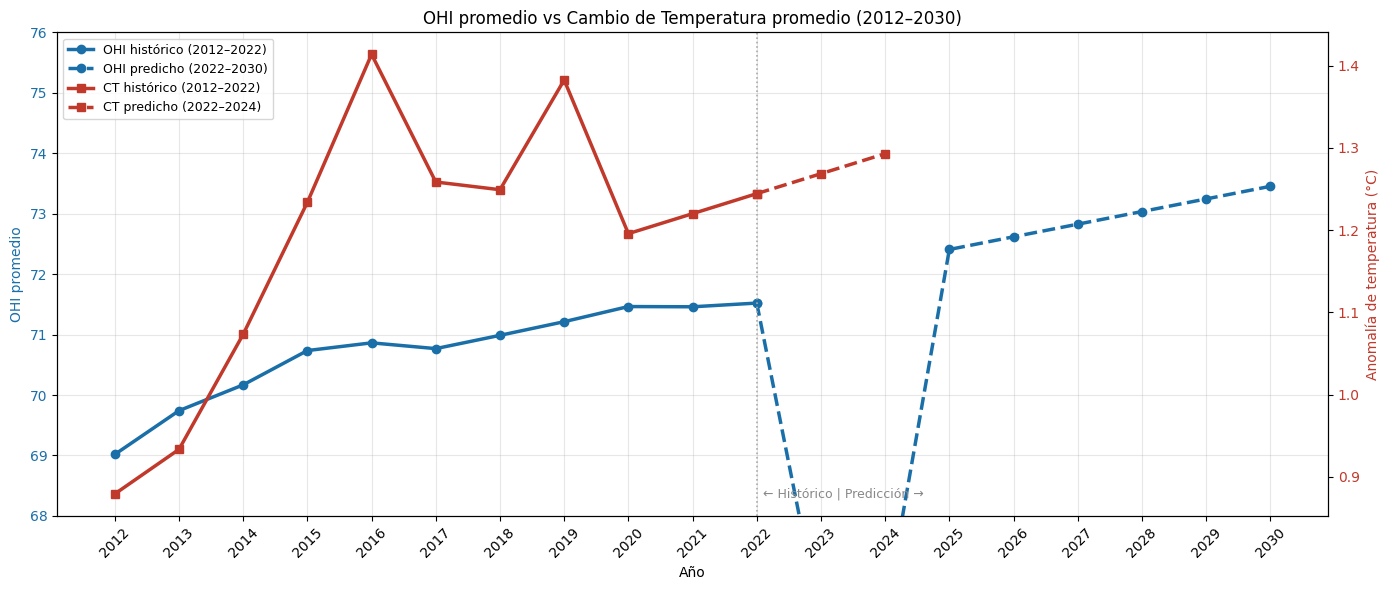

Países OHI_full: 165
Países CT_full:  269


In [110]:
import matplotlib.pyplot as plt

hist_years_ohi = list(range(2012, 2023))   # 2012–2022
pred_years_ohi = list(range(2022, 2031))   # 2022–2030
ct_hist_years  = list(range(2012, 2023))   # CT histórico 2012–2022
ct_pred_years  = list(range(2022, 2025))   # CT predicho 2022–2024 (conecta desde 2022)

# Promedios OHI
ohi_hist_means = [OHI_full[str(y)].mean() for y in hist_years_ohi]
ohi_pred_means = [OHI_full[str(y)].mean() for y in pred_years_ohi]

# Promedios CT
ct_hist_means = [CT_full[f'Y{y}'].mean() for y in ct_hist_years]
ct_pred_means = [CT_full[f'Y{y}'].mean() for y in ct_pred_years]

fig, ax1 = plt.subplots(figsize=(14, 6))

# OHI histórico
color_ohi = '#1a6fa8'
ax1.plot(hist_years_ohi, ohi_hist_means, color=color_ohi, linewidth=2.5,
         marker='o', markersize=6, label='OHI histórico (2012–2022)')

# OHI predicho
ax1.plot(pred_years_ohi, ohi_pred_means, color=color_ohi, linewidth=2.5,
         marker='o', markersize=6, linestyle='--', label='OHI predicho (2022–2030)')

ax1.set_ylabel('OHI promedio', color=color_ohi)
ax1.tick_params(axis='y', labelcolor=color_ohi)
ax1.set_ylim(68, 76)

# CT — eje derecho
ax2 = ax1.twinx()
color_ct = '#c0392b'
ax2.plot(ct_hist_years, ct_hist_means, color=color_ct, linewidth=2.5,
         marker='s', markersize=6, linestyle='-', label='CT histórico (2012–2022)')
ax2.plot(ct_pred_years, ct_pred_means, color=color_ct, linewidth=2.5,
         marker='s', markersize=6, linestyle='--', label='CT predicho (2022–2024)')
ax2.set_ylabel('Anomalía de temperatura (°C)', color=color_ct)
ax2.tick_params(axis='y', labelcolor=color_ct)

# Separador
ax1.axvline(x=2022, color='#aaaaaa', linestyle=':', linewidth=1.2)
ax1.text(2022.1, 68.3, '← Histórico | Predicción →', fontsize=9, color='#888888')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('OHI promedio vs Cambio de Temperatura promedio (2012–2030)', fontsize=12)
ax1.set_xlabel('Año')
ax1.set_xticks(list(range(2012, 2031)))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Países OHI_full: {len(OHI_full)}")
print(f"Países CT_full:  {len(CT_full)}")

Se ve la tendencia positiva, pero no es igual al primer gráfico ya que hay menos paises

In [109]:
OHI_full.to_csv('OHI_full.csv', index=False)
CT_full.to_csv('CT_full.csv', index=False)

print("OHI_full exportado — Shape:", OHI_full.shape)
print("CT_full exportado  — Shape:", CT_full.shape)

OHI_full exportado — Shape: (165, 21)
CT_full exportado  — Shape: (269, 66)
